In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

#set font in matplotlib
mpl.rcParams['pdf.fonttype'] = 42

# Load the data from Kintek AutoSF

In [5]:
df = pd.read_csv('20250702_Endpts_Combined.csv')
scaler = MinMaxScaler()

df2 = df.rename(columns={'Uncat_Avg': 'Uncatalyzed'})

for c in df2.columns[1:]:
    if c == 'S1360_2':
        continue
    df2[f'{c}_scaled'] = scaler.fit_transform(df2[c].values.reshape(-1, 1))

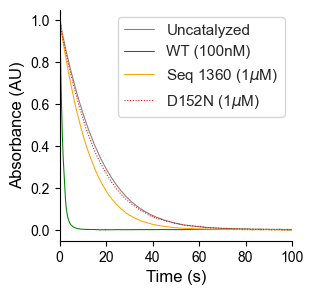

In [6]:
fig, ax = plt.subplots(figsize=(3, 3))

colors = {
    'Uncatalyzed': 'gray',
    'WT': 'green',
    'Seq 1360': 'orange',
    'D152N': 'red',
}

linestyles = {
    'Uncatalyzed': '-',
    'WT': '-',
    'Seq 1360': '-',
    'D152N': ':',
}

sns.set_theme(style="white")

for c in df2.columns[1:]:
    if 'scaled' in c:
        cname = c.replace('_scaled', '')
        if 'WT' in c:
            lname = 'WT (100nM)'
        elif '1360' in c:
            lname = r'Seq 1360 (1$\mu$M)'
        elif 'D152N' in c:
            lname = r'D152N (1$\mu$M)'
        else:
            lname = cname
        sns.lineplot(data=df2, x='Time', y=c, label=lname, ax=ax, linewidth=0.75, color=colors[cname], linestyle=linestyles[cname])

sns.despine(ax=ax, top=True, right=True)
ax.set_xlim(0,100)

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Absorbance (AU)', fontsize=12)

fig.savefig('endpoints_figure.pdf')

# Individual Traces - extracted from original CSV

These have been startpoint normalized - the initial fluorescence intensity is an arbitrary unit, so we just 0'd it.

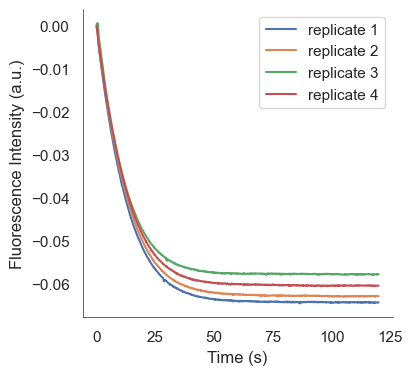

In [7]:
s1360_df = pd.read_csv('1360_traces.csv')
fig, axs = plt.subplots(figsize=(4,4))
axs.plot(s1360_df['Time'], s1360_df['rep1'], label='replicate 1')
axs.plot(s1360_df['Time'], s1360_df['rep2'], label='replicate 2')
axs.plot(s1360_df['Time'], s1360_df['rep3'], label='replicate 3')
axs.plot(s1360_df['Time'], s1360_df['rep4'], label='replicate 4')

axs.legend()
sns.despine()
for spine in axs.spines.values():
    spine.set_linewidth(0.5)

axs.set_xlabel('Time (s)', fontsize=12)
axs.set_ylabel('Fluorescence Intensity (a.u.)', fontsize=12)

fig.savefig('1360_traces.pdf')

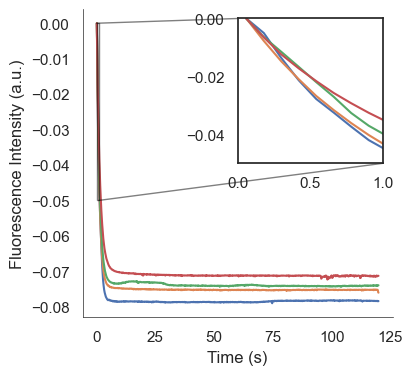

In [8]:
wt_df = pd.read_csv('wt_traces.csv')

fig, axs = plt.subplots(figsize=(4,4))
axs.plot(wt_df['Time'], wt_df['rep1'], label='replicate 1')
axs.plot(wt_df['Time'], wt_df['rep2'], label='replicate 2')
axs.plot(wt_df['Time'], wt_df['rep3'], label='replicate 3')
axs.plot(wt_df['Time'], wt_df['rep5'], label='replicate 4')

axins = axs.inset_axes([0.5, 0.5, 0.47, 0.47])
axins.plot(wt_df['Time'], wt_df['rep1'], label='replicate 1')
axins.plot(wt_df['Time'], wt_df['rep2'], label='replicate 2')
axins.plot(wt_df['Time'], wt_df['rep3'], label='replicate 3')
axins.plot(wt_df['Time'], wt_df['rep5'], label='replicate 4')
axins.set_xlim(0,1)
axins.set_ylim(-0.05, 0)

axs.indicate_inset_zoom(axins, edgecolor="black")

#axs.legend()
sns.despine()
for spine in axs.spines.values():
    spine.set_linewidth(0.5)

axs.set_xlabel('Time (s)', fontsize=12)
axs.set_ylabel('Fluorescence Intensity (a.u.)', fontsize=12)

fig.savefig('wt_traces.pdf')

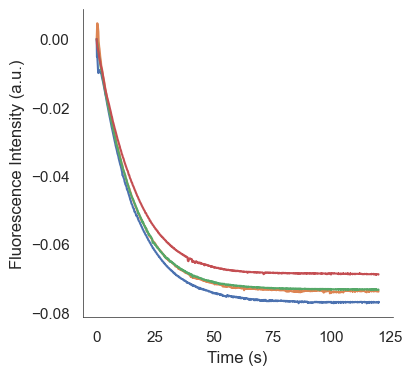

In [9]:
d152n_df = pd.read_csv('d152n_traces.csv')

fig, axs = plt.subplots(figsize=(4,4))
axs.plot(d152n_df['Time'], d152n_df['rep1'], label='replicate 1')
axs.plot(d152n_df['Time'], d152n_df['rep2'], label='replicate 2')
axs.plot(d152n_df['Time'], d152n_df['rep3'], label='replicate 3')
axs.plot(d152n_df['Time'], d152n_df['rep4'], label='replicate 4')

#axs.legend()
sns.despine()
for spine in axs.spines.values():
    spine.set_linewidth(0.5)

axs.set_xlabel('Time (s)', fontsize=12)
axs.set_ylabel('Fluorescence Intensity (a.u.)', fontsize=12)

fig.savefig('d152n_traces.pdf')